In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('diabetes.csv')
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['Outcome'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")

DATASET OVERVIEW
Shape: (768, 9)

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Missing values:
0 total


In [3]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())

In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [6]:
print("BASELINE ANN MODEL")
print("=" * 60)

baseline = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)
baseline.fit(X_train_sc, y_train)
base_pred = baseline.predict(X_test_sc)
base_acc  = accuracy_score(y_test, base_pred)
print(f"Baseline Accuracy : {base_acc:.4f}")


BASELINE ANN MODEL
Baseline Accuracy : 0.7987


In [7]:
print("\n" + "=" * 60)
print("PARAMETRIC TUNING — GridSearchCV")
print("=" * 60)

param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64), (128, 64, 32)],
    'activation'        : ['relu', 'tanh'],
    'alpha'             : [0.0001, 0.001, 0.01],    
    'learning_rate_init': [0.001, 0.01],
    'solver'            : ['adam'],
    'max_iter'          : [500]
}

ann = MLPClassifier(random_state=42)
grid_search = GridSearchCV(
    ann,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_sc, y_train)

print(f"\nBest Parameters  : {grid_search.best_params_}")
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")



PARAMETRIC TUNING — GridSearchCV
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters  : {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'adam'}
Best CV Accuracy : 0.7574


In [8]:
best_model = grid_search.best_estimator_
y_pred  = best_model.predict(X_test_sc)
y_prob  = best_model.predict_proba(X_test_sc)[:, 1]

test_acc  = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)
cv_scores = cross_val_score(best_model, X_train_sc, y_train, cv=5)

In [9]:
print("\n" + "=" * 60)
print("BEST MODEL EVALUATION")
print("=" * 60)
print(f"Test  Accuracy   : {test_acc:.4f}")
print(f"ROC-AUC Score    : {roc_auc:.4f}")
print(f"5-Fold CV Mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")


BEST MODEL EVALUATION
Test  Accuracy   : 0.7403
ROC-AUC Score    : 0.8233
5-Fold CV Mean   : 0.7574 ± 0.0368

Classification Report:

              precision    recall  f1-score   support

 No Diabetes       0.79      0.82      0.80       100
    Diabetes       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154

Confusion Matrix:
[[82 18]
 [22 32]]


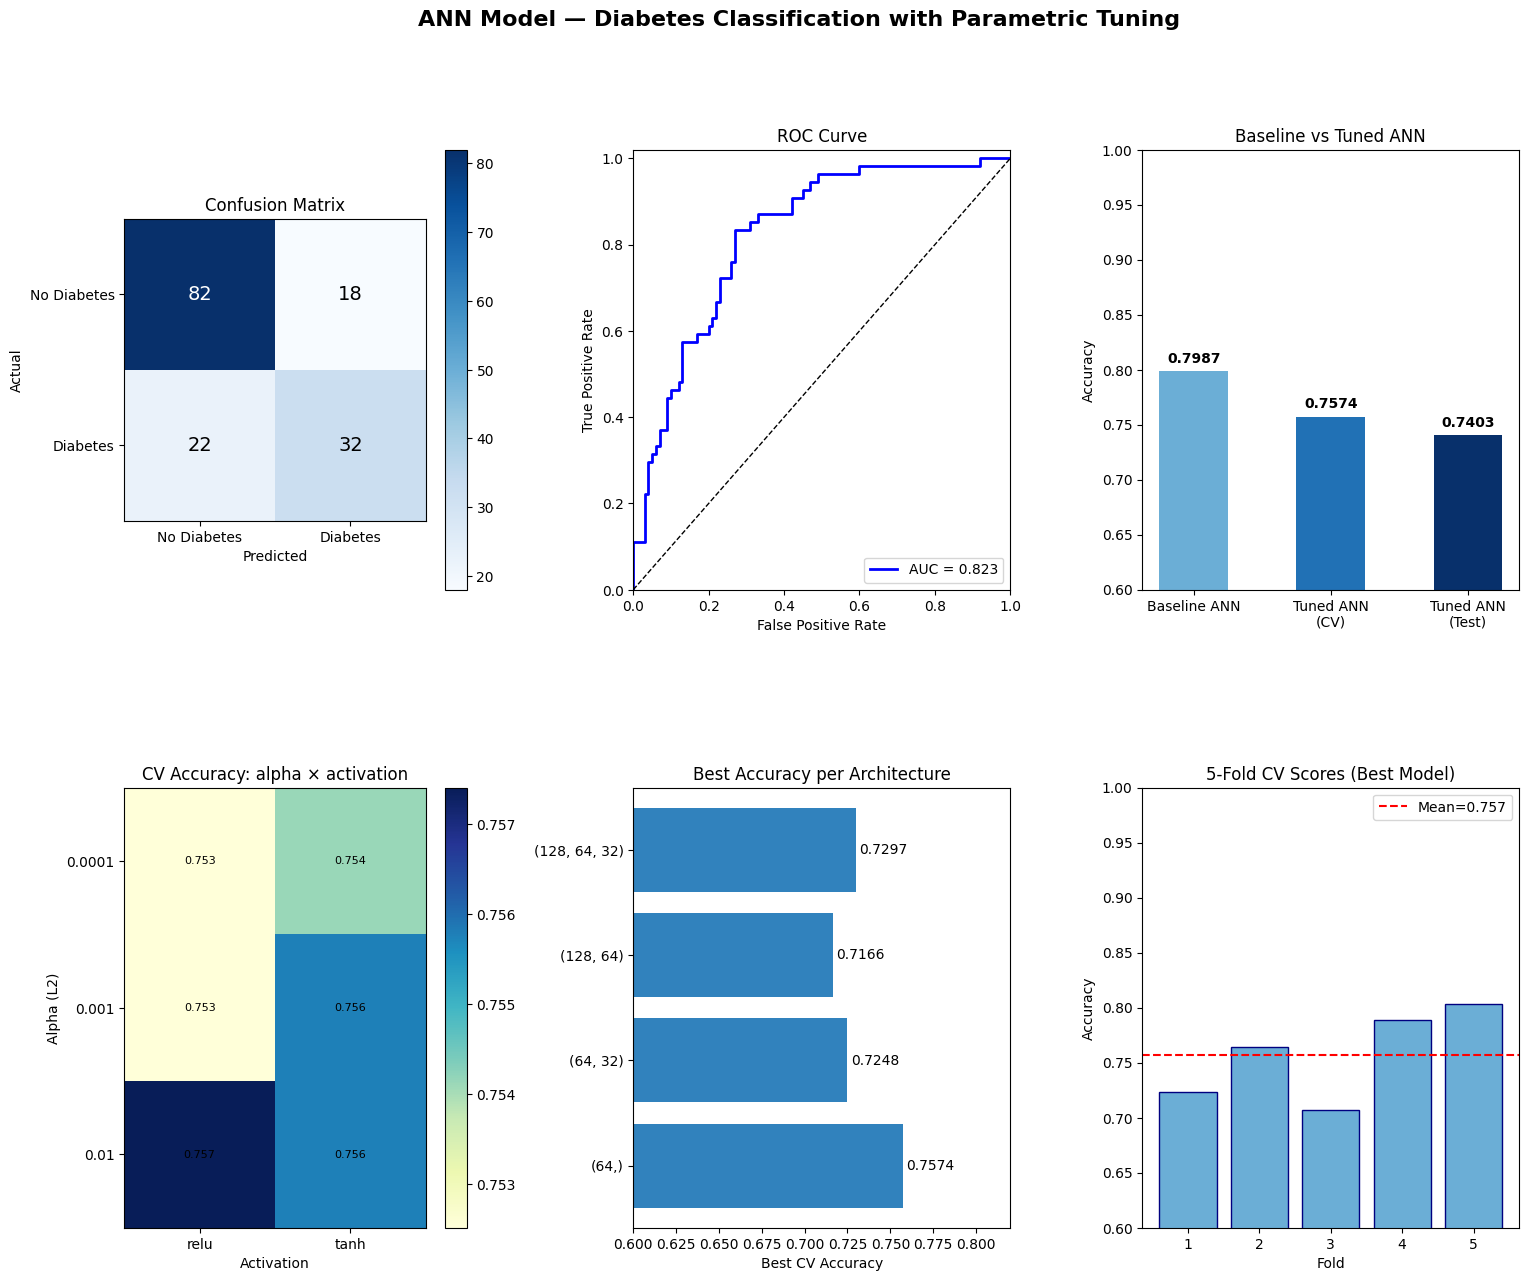

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

fig = plt.figure(figsize=(18, 14))
fig.suptitle("ANN Model — Diabetes Classification with Parametric Tuning",
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── A. Confusion Matrix ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
im = ax1.imshow(cm, cmap='Blues')
ax1.set_xticks([0,1]); ax1.set_yticks([0,1])
ax1.set_xticklabels(['No Diabetes','Diabetes'])
ax1.set_yticklabels(['No Diabetes','Diabetes'])
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, cm[i,j], ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax1)

# ── B. ROC Curve ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {roc_auc:.3f}')
ax2.plot([0,1],[0,1],'k--', lw=1)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc='lower right')
ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])

# ── C. Baseline vs Tuned ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
models = ['Baseline ANN', 'Tuned ANN\n(CV)', 'Tuned ANN\n(Test)']
scores = [base_acc, grid_search.best_score_, test_acc]
bars = ax3.bar(models, scores, color=['#6baed6','#2171b5','#08306b'], width=0.5)
ax3.set_ylim(0.6, 1.0)
ax3.set_ylabel('Accuracy')
ax3.set_title('Baseline vs Tuned ANN')
for bar, score in zip(bars, scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# ── D. Heatmap: alpha × activation ───────────
ax4 = fig.add_subplot(gs[1, 0])
heatmap = ax4.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
ax4.set_xticks(range(len(pivot.columns)))
ax4.set_xticklabels(pivot.columns)
ax4.set_yticks(range(len(pivot.index)))
ax4.set_yticklabels(pivot.index)
ax4.set_xlabel('Activation'); ax4.set_ylabel('Alpha (L2)')
ax4.set_title('CV Accuracy: alpha × activation')
plt.colorbar(heatmap, ax=ax4)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax4.text(j, i, f'{pivot.values[i,j]:.3f}', ha='center', va='center', fontsize=8)

# ── E. CV Score per Architecture ─────────────
ax5 = fig.add_subplot(gs[1, 1])
arch_results = results_df.groupby('param_hidden_layer_sizes')['mean_test_score'].max()
arch_labels  = [str(x) for x in arch_results.index]
ax5.barh(arch_labels, arch_results.values, color='#3182bd')
ax5.set_xlabel('Best CV Accuracy')
ax5.set_title('Best Accuracy per Architecture')
for i, v in enumerate(arch_results.values):
    ax5.text(v + 0.002, i, f'{v:.4f}', va='center')
ax5.set_xlim(0.6, 0.82)

# ── F. Cross-Validation Score Distribution ───
ax6 = fig.add_subplot(gs[1, 2])
ax6.bar(range(1, 6), cv_scores, color='#6baed6', edgecolor='navy')
ax6.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.3f}')
ax6.set_xlabel('Fold'); ax6.set_ylabel('Accuracy')
ax6.set_title('5-Fold CV Scores (Best Model)')
ax6.set_ylim(0.6, 1.0)
ax6.legend()

plt.tight_layout()
plt.show()

In [22]:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
bp = grid_search.best_params_
print(f"""
┌──────────────────────────────────────────┐
│          BEST MODEL CONFIGURATION        │
├──────────────────────────────────────────┤
│  Architecture : {str(bp['hidden_layer_sizes']):<25}│
│  Activation   : {bp['activation']:<25}│
│  Alpha (L2)   : {bp['alpha']:<25}│
│  Learning Rate: {bp['learning_rate_init']:<25}│
│  Solver       : {bp['solver']:<25}│
├──────────────────────────────────────────┤
│          PERFORMANCE METRICS             │
├──────────────────────────────────────────┤
│  Baseline Accuracy : {base_acc:.4f}               │
│  Best CV Accuracy  : {grid_search.best_score_:.4f}               │
│  Best CV Accuracy  : {grid_search.best_score_:.4f}               │
│  Test Accuracy     : {test_acc:.4f}               │
│  ROC-AUC           : {roc_auc:.4f}               │
└──────────────────────────────────────────┘
""")


SUMMARY

┌──────────────────────────────────────────┐
│          BEST MODEL CONFIGURATION        │
├──────────────────────────────────────────┤
│  Architecture : (64,)                    │
│  Activation   : relu                     │
│  Alpha (L2)   : 0.01                     │
│  Learning Rate: 0.001                    │
│  Solver       : adam                     │
├──────────────────────────────────────────┤
│          PERFORMANCE METRICS             │
├──────────────────────────────────────────┤
│  Baseline Accuracy : 0.7987               │
│  Best CV Accuracy  : 0.7574               │
│  Best CV Accuracy  : 0.7574               │
│  Test Accuracy     : 0.7403               │
│  ROC-AUC           : 0.8233               │
└──────────────────────────────────────────┘

